In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Environment ready!
NumPy: 1.21.5
pandas: 1.4.2
scikit-learn: 1.0.2


In [14]:
df = pd.read_csv("student_performanc.csv")
df.head()

,study_hours,attendance,assignments,result
0,5,80,8,Pass
1,2,60,5,Fail
2,7,90,9,Pass
3,1,50,4,Fail
4,8,95,10,Pass


In [15]:
df.groupby("result")[["study_hours","attendance","assignments"]].mean()

,study_hours,attendance,assignments
result,,,
Fail,2.5,60.4,4.8
Pass,7.0,88.3,8.8


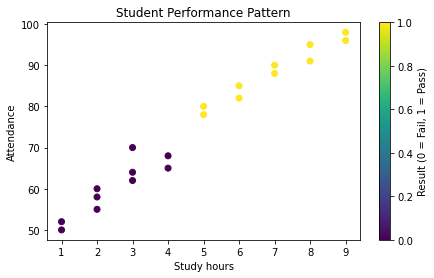

X shape: (20, 3)
y shape: (20,)


In [17]:
import matplotlib.pyplot as plt


color_map = df["result"].map({"Pass": 1, "Fail": 0})

# Scatter plot
plt.figure(figsize=(7, 4))

plt.scatter(
    df["study_hours"],
    df["attendance"],
    c=color_map,
    cmap="viridis"
)

plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student Performance Pattern")

plt.colorbar(label="Result (0 = Fail, 1 = Pass)")

plt.show()


# Features and target
X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Training rows: 16
Testing rows : 4
Model trained!


In [19]:
predictions = model.predict(X_test)

print ("Predictions:")
print (predictions)
print ("X_test: ")
print (X_test)

Predictions:
['Fail' 'Fail' 'Pass' 'Pass']
X_test: 
    study_hours  attendance  assignments
13            1          52            4
7             4          65            6
4             8          95           10
12            8          91            9


In [20]:
accuracy = accuracy_score(y_test, predictions)
print (f"Test accuracy: {accuracy: .2%}")

Test accuracy:  100.00%


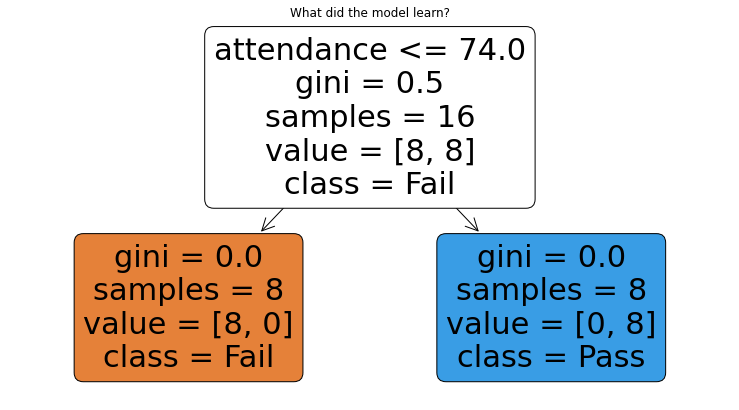

In [21]:
plt.figure(figsize=(13, 7))
plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True, 
    rounded=True
)
plt.title("What did the model learn?")
plt.show()